In [2]:
import pandas as pd
import torch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, TensorDataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import math
import copy


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ipyk

## Data loading and transformations

In [3]:
# Load data from CSV files
train_data = pd.read_csv('../data/mnist_train.csv')
test_data = pd.read_csv('../data/mnist_test.csv')

# Separate features and labels
# Column 0 is the label.
# Columns 1 onward are the 784 pixels.
X_train = train_data.iloc[:, 1:].values.reshape(-1, 1, 28, 28) / 255.0
y_train = train_data.iloc[:, 0].values

X_test = test_data.iloc[:, 1:].values.reshape(-1, 1, 28, 28) / 255.0
y_test = test_data.iloc[:, 0].values

# Normalize from [0, 1] to [-1, 1]
X_train = (X_train - 0.5) / 0.5
X_test = (X_test - 0.5) / 0.5

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create full training dataset
full_train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Split training into train/validation (10% for validation)
val_size = int(0.1 * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size

generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=generator
)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Train size: {len(train_dataset)}, Validation size: {len(val_dataset)}, Test size: {len(test_dataset)}")

Train size: 54000, Validation size: 6000, Test size: 10000


### Define LeNet-5

In [4]:
class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.AvgPool2d(2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16*4*4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = torch.tanh(self.conv1(x))
        x = self.pool(x)
        x = torch.tanh(self.conv2(x))
        x = self.pool(x)
        x = x.view(-1, 16*4*4)
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = self.fc3(x)
        return x

### Evaluation function

In [5]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            outputs = model(x)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y).sum().item()
            total += y.size(0)
    return 100 * correct / total

## Baseline Training

In [6]:
baseline_lr = 0.01
baseline_epochs = 50
model_baseline = LeNet5()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_baseline.parameters(), lr=baseline_lr)

train_losses = []

for epoch in range(baseline_epochs):
    model_baseline.train()
    running_loss = 0
    for x, y in train_loader:
        optimizer.zero_grad()
        outputs = model_baseline(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_losses.append(running_loss / len(train_loader))

### Evaluate final accuracy

In [7]:
val_acc_baseline = evaluate(model_baseline, val_loader)
test_acc_baseline = evaluate(model_baseline, test_loader)
print(f"Baseline Model: Validation Accuracy = {val_acc_baseline:.2f}%, Test Accuracy = {test_acc_baseline:.2f}%")

Baseline Model: Validation Accuracy = 98.50%, Test Accuracy = 98.72%


## Simulated Annealing for LR

In [8]:
initial_temperature = 10.0
final_temperature = 0.1
alpha = 0.9  # cooling rate
current_temperature = initial_temperature

current_lr = 0.01
best_val_acc = 0
best_lr = current_lr
best_model_state = None

### Track data for plots

In [9]:
temperatures = []
learning_rates = []
val_accuracies = []
test_accuracies = []

while current_temperature > final_temperature:
    # New model for each candidate
    model = LeNet5()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=current_lr)
    
    # Train a few epochs per candidate
    epochs_per_candidate = 5
    for epoch in range(epochs_per_candidate):
        model.train()
        for x, y in train_loader:
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
    
    # Evaluate
    val_acc = evaluate(model, val_loader)
    test_acc = evaluate(model, test_loader)
    
    # Record
    temperatures.append(current_temperature)
    learning_rates.append(current_lr)
    val_accuracies.append(val_acc)
    test_accuracies.append(test_acc)
    
    # Accept new LR probabilistically
    delta = val_acc - best_val_acc
    if delta > 0 or math.exp(delta / current_temperature) > torch.rand(1).item():
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_lr = current_lr
            best_model_state = copy.deepcopy(model.state_dict())
    
    # Random perturbation of LR
    current_lr = max(0.0001, current_lr + (torch.randn(1).item() * 0.005))
    
    # Cool down
    current_temperature *= alpha
    
print(f"Simulated Annealing: Best validation accuracy = {best_val_acc:.2f}% at learning rate = {best_lr:.4f}")

Simulated Annealing: Best validation accuracy = 96.43% at learning rate = 0.0254


## Plotting

In [13]:
plt.figure(figsize=(16,16))

<Figure size 1600x1600 with 0 Axes>

<Figure size 1600x1600 with 0 Axes>

### Training loss

Text(0.5, 1.0, 'Baseline Training Loss vs Epochs')

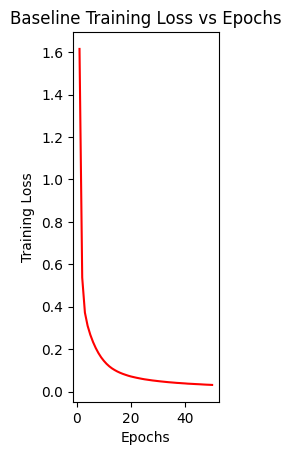

In [14]:
plt.subplot(1,3,1)
plt.plot(range(1, baseline_epochs+1), train_losses, color='red')
plt.xlabel('Epochs')
plt.ylabel('Training Loss')
plt.title('Baseline Training Loss vs Epochs')

### Validation accuracy vs Temperature

Text(0.5, 1.0, 'Validation Accuracy vs Temperature')

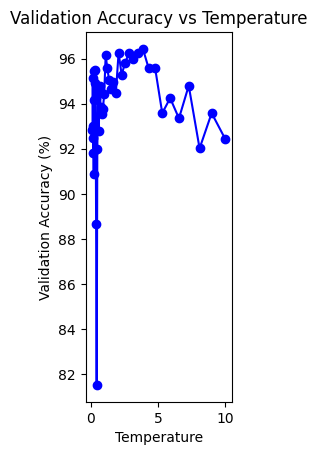

In [12]:
plt.subplot(1,3,2)
plt.plot(temperatures, val_accuracies, color='blue', marker='o')
plt.xlabel('Temperature')
plt.ylabel('Validation Accuracy (%)')
plt.title('Validation Accuracy vs Temperature')

### Test accuracy vs Learning Rate

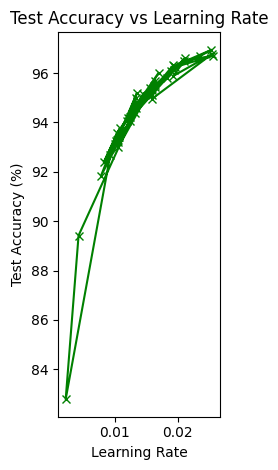

In [15]:
plt.subplot(1,3,3)
plt.plot(learning_rates, test_accuracies, color='green', marker='x')
plt.xlabel('Learning Rate')
plt.ylabel('Test Accuracy (%)')
plt.title('Test Accuracy vs Learning Rate')

plt.tight_layout()
plt.show()